# Model overview

Refer to the paper and the [Model Overview](../index.qmd) section for a conceptual overview of the model.

# Detect computing environment

If using Google Colab, mount the drive and set the base directory to the working folder. If using local, set the base directory.

In [1]:
import os       # Operating system utilities
import sys

# Detect environment
def is_colab():
    """Returns True if running in Google Colab, False otherwise."""
    try:
        import google.colab
        return True
    except ImportError:
        return False

# Set up environment-specific configurations
if is_colab():

    # Colab-specific setup
    !pip install rasterio
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/GitHub/deepSSF/Python')

    # for saving plots etc
    base_path = '/content/drive/MyDrive/GitHub/deepSSF'
    print("Running in Google Colab environment")

else:

    # Local environment setup
    base_path = '..'
    print("Running in local environment")

# Now you can use base_path regardless of environment
print(f"Using base path: {base_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 86.4 MB/s eta 0:00:00
Mounted at /content/drive
Running in Google Colab environment
Using base path: /content/drive/MyDrive/GitHub/deepSSF


## Import packages

In [2]:
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import mpmath as mp                                     # Math library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                   # Neural network modules
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data
import time                                             # To get time information

from torch.utils.data import Dataset, DataLoader        # Dataset and batch data loading
from datetime import datetime                           # Date/time utilities
from rasterio.plot import show                           # Plot raster data

n_conv_layers = 2
import deepSSF_model_conv2 as deepSSF_model             # Import the .py file containing the deepSSF model
import deepSSF_loss                                     # Import the .py file containing the deepSSF loss function
import deepSSF_early_stopping                           # Import the .py file containing the early stopping function

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')

# Set random seed for reproducibility
seed = 42

3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]


# Prepare data

In [3]:
# select the id to train the model on
buffalo_id = 2005
# in our case the actual dataset will be slightly smaller due to steps being removed that were outside the extent
n_samples = 10297

# Specify the path to CSV file
csv_file_path = f'{base_path}/buffalo_local_data_id/buffalo_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'

# Path to your TIF file
ndvi_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_ndvi_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
canopy_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_canopy_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
herby_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_herby_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
slope_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_slope_cent101x101_lag_1hr_n{n_samples}.tif'

# Path to your TIF file
pres_path = f'{base_path}/buffalo_local_layers_id/fixed_buffalo_{buffalo_id}_pres_cent101x101_lag_1hr_n{n_samples}.tif'

## Read buffalo data

In [4]:
# Read the CSV file into a DataFrame
buffalo_df = pd.read_csv(csv_file_path)
print(buffalo_df.shape)

# Lag the values in column 'A' by one index to get the bearing of the previous step
buffalo_df['bearing_tm1'] = buffalo_df['bearing'].shift(1)
# Pad the missing value with a specified value, e.g., 0
buffalo_df['bearing_tm1'] = buffalo_df['bearing_tm1'].fillna(0)

# Display the first few rows of the DataFrame
print(buffalo_df.head())

(10103, 32)
             x_            y_                    t_    id           x1_  \
0  41969.310875 -1.435671e+06  2018-07-25T01:04:23Z  2005  41969.310875   
1  41921.521939 -1.435654e+06  2018-07-25T02:04:39Z  2005  41921.521939   
2  41779.439594 -1.435601e+06  2018-07-25T03:04:17Z  2005  41779.439594   
3  41841.203272 -1.435635e+06  2018-07-25T04:04:39Z  2005  41841.203272   
4  41655.463332 -1.435604e+06  2018-07-25T05:04:27Z  2005  41655.463332   

            y1_           x2_           y2_     x2_cent    y2_cent  ...  \
0 -1.435671e+06  41921.521939 -1.435654e+06  -47.788936  16.857110  ...   
1 -1.435654e+06  41779.439594 -1.435601e+06 -142.082345  53.568427  ...   
2 -1.435601e+06  41841.203272 -1.435635e+06   61.763677 -34.322938  ...   
3 -1.435635e+06  41655.463332 -1.435604e+06 -185.739939  31.003534  ...   
4 -1.435604e+06  41618.651923 -1.435608e+06  -36.811409  -4.438037  ...   

  bearing_sin  bearing_cos        ta    cos_ta         x_min         x_max  \
0    0.3

# Spatial data

## NDVI

In [5]:
# Using rasterio
with rasterio.open(ndvi_path) as ndvi:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    ndvi_stack = ndvi.read([i for i in range(1, ndvi.count + 1)])

print(ndvi_stack.shape)

(10103, 101, 101)


### Normalise the layers

In [6]:
# Replace NaNs in the original array with -1, which represents water
ndvi_stack = np.nan_to_num(ndvi_stack, nan=-1.0)

# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
ndvi_tens = torch.from_numpy(ndvi_stack)

# Print the shape of the PyTorch tensor
print(ndvi_tens.shape)

# Print the mean, max, and min values of the NDVI tensor
ndvi_mean = torch.mean(ndvi_tens)
ndvi_max = torch.max(ndvi_tens)
ndvi_min = torch.min(ndvi_tens)
print("Mean = ", ndvi_mean)
print("Max = ", ndvi_max)
print("Min = ", ndvi_min)

# Normalizing the data
ndvi_tens_norm = (ndvi_tens - ndvi_min) / (ndvi_max - ndvi_min)
print("Mean = ", torch.mean(ndvi_tens_norm))
print("Max = ", torch.max(ndvi_tens_norm))
print("Min = ", torch.min(ndvi_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.3039)
Max =  tensor(0.8220)
Min =  tensor(-0.2772)
Mean =  tensor(0.5287)
Max =  tensor(1.)
Min =  tensor(0.)


Plot a single NDVI layer

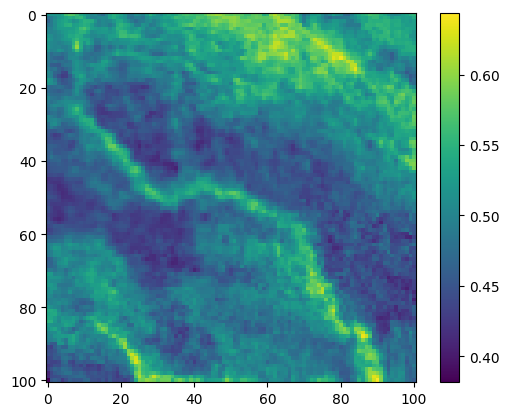

In [7]:
for i in range(0, 1):
    plt.imshow(ndvi_tens_norm[i].numpy())
    plt.colorbar()
    plt.show()

## Canopy cover

In [8]:
# Using rasterio
with rasterio.open(canopy_path) as canopy:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    canopy_stack = canopy.read([i for i in range(1, canopy.count + 1)])

print(canopy_stack.shape)

(10103, 101, 101)


In [9]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
canopy_tens = torch.from_numpy(canopy_stack)
print(canopy_tens.shape)

# Print the mean, max, and min values of the canopy tensor
print("Mean = ", torch.mean(canopy_tens))
canopy_max = torch.max(canopy_tens)
canopy_min = torch.min(canopy_tens)
print("Max = ", canopy_max)
print("Min = ", canopy_min)

# Normalizing the data
canopy_tens_norm = (canopy_tens - canopy_min) / (canopy_max - canopy_min)
print("Mean = ", torch.mean(canopy_tens_norm))
print("Max = ", torch.max(canopy_tens_norm))
print("Min = ", torch.min(canopy_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(44.3548)
Max =  tensor(82.5000)
Min =  tensor(0.)
Mean =  tensor(0.5376)
Max =  tensor(1.)
Min =  tensor(0.)


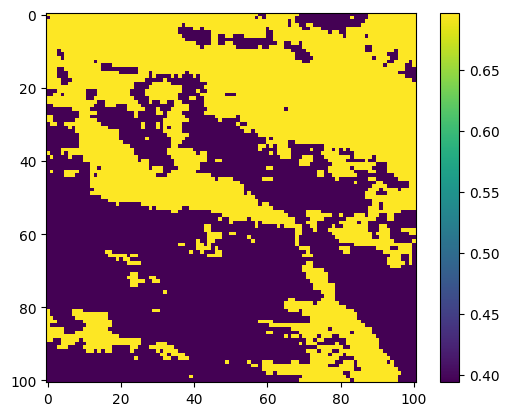

In [10]:
for i in range(0, 1):
    plt.imshow(canopy_tens_norm[i].numpy())
    plt.colorbar()
    plt.show()

## Herbaceous vegetation

In [11]:
# Using rasterio
with rasterio.open(herby_path) as herby:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    herby_stack = herby.read([i for i in range(1, herby.count + 1)])

print(herby_stack.shape)

(10103, 101, 101)


In [12]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
herby_tens = torch.from_numpy(herby_stack)
print(herby_tens.shape)

# Print the mean, max, and min values of the herby tensor
print("Mean = ", torch.mean(herby_tens))
herby_max = torch.max(herby_tens)
herby_min = torch.min(herby_tens)
print("Max = ", herby_max)
print("Min = ", herby_min)

# Normalizing the data
herby_tens_norm = (herby_tens - herby_min) / (herby_max - herby_min)
print("Mean = ", torch.mean(herby_tens_norm))
print("Max = ", torch.max(herby_tens_norm))
print("Min = ", torch.min(herby_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.8069)
Max =  tensor(1.)
Min =  tensor(0.)
Mean =  tensor(0.8069)
Max =  tensor(1.)
Min =  tensor(0.)


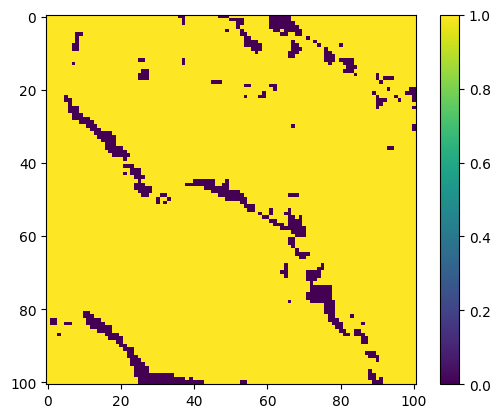

In [13]:
for i in range(0, 1):
    plt.imshow(herby_tens_norm[i])
    plt.colorbar()
    plt.show()

## Slope

In [14]:
# Using rasterio
with rasterio.open(slope_path) as slope:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    slope_stack = slope.read([i for i in range(1, slope.count + 1)])

print(slope_stack.shape)

(10103, 101, 101)


In [15]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
slope_tens = torch.from_numpy(slope_stack)
print(slope_tens.shape)

# Print the mean, max, and min values of the slope tensor
print("Mean = ", torch.mean(slope_tens))
slope_max = torch.max(slope_tens)
slope_min = torch.min(slope_tens)
print("Max = ", slope_max)
print("Min = ", slope_min)

# Normalizing the data
slope_tens_norm = (slope_tens - slope_min) / (slope_max - slope_min)
print("Mean = ", torch.mean(slope_tens_norm))
print("Max = ", torch.max(slope_tens_norm))
print("Min = ", torch.min(slope_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.7779)
Max =  tensor(12.2981)
Min =  tensor(0.0006)
Mean =  tensor(0.0632)
Max =  tensor(1.)
Min =  tensor(0.)


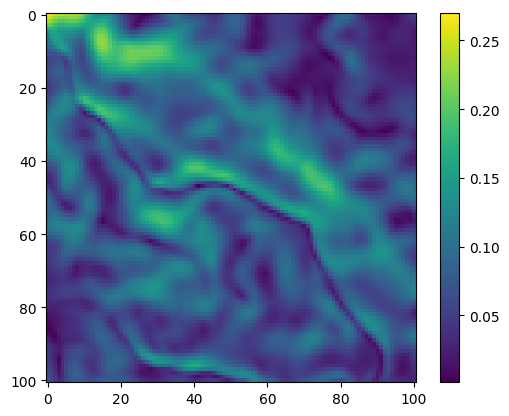

In [16]:
for i in range(0, 1):
    plt.imshow(slope_tens_norm[i])
    plt.colorbar()
    plt.show()

## Presence records - target of model

This is what the model is trying to predict, which is the location of the next step.

In [17]:
# Using rasterio
with rasterio.open(pres_path) as pres:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    pres_stack = pres.read([i for i in range(1, pres.count + 1)])

print(pres_stack.shape)

(10103, 101, 101)


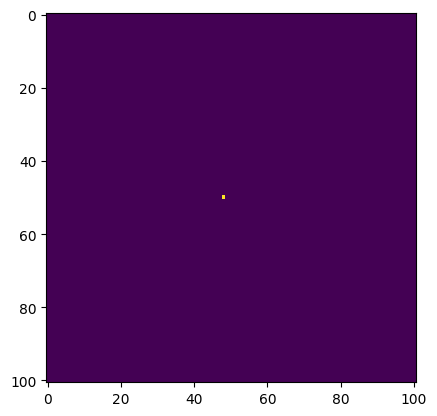

In [18]:
for i in range(0, 1):
    plt.imshow(pres_stack[i])
    plt.show()

In [19]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using {device} device")

Using cuda device


### Combine the spatial layers into channels

In [20]:
# Stack the channels along a new axis; here, 1 is commonly used for the channel axis in PyTorch
combined_stack = torch.stack([ndvi_tens_norm,
                              canopy_tens_norm,
                              herby_tens_norm,
                              slope_tens_norm],
                              dim=1)

print(combined_stack.shape)

torch.Size([10103, 4, 101, 101])


From the size we can see that there are 10103 samples (steps), 4 channels (layers = covariates) and 101x101 pixels.

## Defining data sets and data loaders

### Creating a dataset class

This custom PyTorch Dataset organizes all your input (spatial data, scalar covariates, bearing, and target) in a single object, allowing you to neatly manage how samples are accessed. The `__init__` method prepares and stores all the data, `__len__` returns the total number of samples, and `__getitem__` retrieves a single sample by index—enabling straightforward batching and iteration when used with a DataLoader.


![](../figures/model_diagram_inputs.png)

In [21]:
class buffalo_data(Dataset):

    def __init__(self):
        # data loading. Here we are just using the combined_stack as the spatial covariates
        self.spatial_data_x = combined_stack

        # the scalar data that will be converted to spatial data and added as channels to the spatial covariates
        self.scalar_to_grid_data = torch.from_numpy(buffalo_df[['hour_t2_sin',
                                                                'hour_t2_cos',
                                                                'yday_t2_sin',
                                                                'yday_t2_cos']].values).float()

        # the bearing data that will be added as a channel to the spatial covariates
        self.bearing_x = torch.from_numpy(buffalo_df[['bearing_tm1']].values).float()

        # the target data
        self.target = torch.tensor(pres_stack)

        # number of samples
        self.n_samples = self.spatial_data_x.shape[0]

    def __len__(self):
        # allows for the use of len() function
        return self.n_samples

    def __getitem__(self, index):
        # allows for indexing of the dataset
        return self.spatial_data_x[index], self.scalar_to_grid_data[index], self.bearing_x[index], self.target[index]

Now we can create an instance of the dataset class and check that is working as expected.

In [22]:
# Create an instance of our custom buffalo_data Dataset:
dataset = buffalo_data()

# Print the total number of samples loaded (determined by n_samples in the dataset):
n_samples_loaded = dataset.n_samples
print(n_samples_loaded)

# Retrieve *all* samples (using the slice dataset[:] invokes __getitem__ on all indices).
# This returns a tuple of (spatial data, scalar-to-grid data, bearing data, target labels).
features1, features2, features3, labels = dataset[:]

# Examine the dimensions of each returned tensor for verification:

# Spatial data
print(features1.shape)

# Scalar-to-grid data
print(features2.shape)

# Bearing data
print(features3.shape)

# Target labels
print(labels.shape)

10103
torch.Size([10103, 4, 101, 101])
torch.Size([10103, 4])
torch.Size([10103, 1])
torch.Size([10103, 101, 101])


### Split into training, validation and test sets

Uncomment either the random split or the sequential split to use the one you prefer. A sequential split requires more of an extrapolation, as the individual could have encountered a different environmental region in the latter part of the time series, or it could be from a different time period, such as part of a season that isn't in the training data.

For testing we will therefore use the sequential split as more of a test for the model.

In [23]:
training_split = 0.8 # 80% of the data will be used for training
validation_split = 0.1 # 10% of the data will be used for validation (deciding when to stop training)
test_split = 0.1 # 10% of the data will be used for testing (model evaluation)

To split the samples randomly we can use the `random_split` function from PyTorch

In [24]:
# dataset_train, dataset_val, dataset_test = torch.utils.data.random_split(dataset, [training_split, validation_split, test_split])

To split the data sequentially, we can use the `Subset` function from PyTorch, which allows us to select a subset of the data based on the indices we provide.

In [25]:
# For sequential split (need integers)
n_samples = len(dataset)
n_train = int(training_split * n_samples)
n_val = int(validation_split * n_samples)
n_test = n_samples - n_train - n_val  # Ensure they sum to total number of samples

# Get the start and end indices for each split
train_end = int(training_split * n_samples)
val_end = int((training_split + validation_split) * n_samples)

train_indices = list(range(0, train_end))
val_indices = list(range(train_end, val_end))
test_indices = list(range(val_end, len(dataset)))

# to split the samples sequentially
dataset_train = torch.utils.data.Subset(dataset, train_indices)
dataset_val = torch.utils.data.Subset(dataset, val_indices)
dataset_test = torch.utils.data.Subset(dataset, test_indices)

print("Number of training samples: ",   len(dataset_train))
print("Number of validation samples: ", len(dataset_val))
print("Number of testing samples: ",    len(dataset_test))

Number of training samples:  8082
Number of validation samples:  1010
Number of testing samples:  1011


### Create dataloaders

The DataLoader in PyTorch wraps an iterable around the Dataset to enable easy access to the samples.

In [26]:
# Define the batch size for how many samples to process at once in each step:
bs = 32

# Create a DataLoader for the training dataset with a batch size of bs, and shuffle samples
# so that the model doesn't see data in the same order each epoch.
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=bs,
                              shuffle=True)

# Create a DataLoader for the validation dataset, also with a batch size of bs and shuffling.
# Even though it's not always mandatory to shuffle validation data, some users keep the same setting.
dataloader_val = DataLoader(dataset=dataset_val,
                            batch_size=bs,
                            shuffle=True)

# Create a DataLoader for the test dataset, likewise with a batch size of bs and shuffling.
# As we want to index the testing data for plotting, we will not shuffle the test data.
dataloader_test = DataLoader(dataset=dataset_test,
                             batch_size=bs,
                             shuffle=False)


Check that the data loader is working as expected.

In [27]:
# Display image and label.
# next(iter(dataloader_train)) returns the next batch of the training data
features1, features2, features3, labels = next(iter(dataloader_train))
print(f"Feature 1 batch shape:  {features1.size()}")
print(f"Feature 2 batch shape:  {features2.size()}")
print(f"Feature 3 batch shape:  {features3.size()}")
print(f"Labels batch shape:     {labels.size()}")

Feature 1 batch shape:  torch.Size([32, 4, 101, 101])
Feature 2 batch shape:  torch.Size([32, 4])
Feature 3 batch shape:  torch.Size([32, 1])
Labels batch shape:     torch.Size([32, 101, 101])


## Pull out some testing data

To test the other blocks, and the full model, we will need some data. We can pull that out from the training set.

As the test set is shuffled, the `iteration_index` is arbitrary and can be changed to any value between 0 and the number of samples in the test set.

In [28]:
# Number of samples in the test dataset
print("Number of samples in the test dataset: ", len(dataloader_test.dataset))
print('\n')

# Select an index from the test dataset to retrieve a sample, between 0 and number of samples
# We picked this fairly arbitrarily, but with some interesting environmental features to illustrate the model's predictions
iteration_index = 240

# 2. Retrieve a single sample (features and label) from the test dataset at the specified index

# sample_spatial_covs is a sample of the spatial covariates for a single step
# sample_temporal_covs is a sample of the temporal covariates for a single step
# sample_prev_bearing is a sample bearing of the previous step
# sample_next_step is the target label (what we are trying to predict) for the next step

# We set these here and will also use them later in the script to check how the model's predictions look,
# and when we extract feature maps from the convolutional layers
sample_spatial_covs, sample_temporal_covs, sample_prev_bearing, sample_next_step = dataloader_test.dataset[iteration_index]

# 3. Reshape data tensors to add a batch dimension (since the model expects batches)
sample_spatial_covs = sample_spatial_covs.unsqueeze(0).to(device)
sample_temporal_covs = sample_temporal_covs.unsqueeze(0).to(device)
sample_prev_bearing = sample_prev_bearing.unsqueeze(0).to(device)
sample_next_step = sample_next_step.unsqueeze(0).to(device)

print(f'Shape of the sample spatial covariates:  {sample_spatial_covs.shape}')
print(f'Shape of the sample temporal covariates: {sample_temporal_covs.shape}')
print(f'Shape of the sample previous bearing:    {sample_prev_bearing.shape}')
print(f'Shape of the sample next step:           {sample_next_step.shape}')

Number of samples in the test dataset:  1011


Shape of the sample spatial covariates:  torch.Size([1, 4, 101, 101])
Shape of the sample temporal covariates: torch.Size([1, 4])
Shape of the sample previous bearing:    torch.Size([1, 1])
Shape of the sample next step:           torch.Size([1, 101, 101])


### For visualisation, we can return the scale of the covariates to their original values.

In [29]:
# 1. NDVI (Normalized Difference Vegetation Index)
ndvi_norm = sample_spatial_covs.detach().cpu()[0, 0, :, :]
ndvi_natural = (ndvi_norm * (ndvi_max - ndvi_min)) + ndvi_min

# 2. Canopy cover
canopy_norm = sample_spatial_covs.detach().cpu()[0, 1, :, :]
canopy_natural = (canopy_norm * (canopy_max - canopy_min)) + canopy_min

# 3. Herbaceous vegetation
herby_norm = sample_spatial_covs.detach().cpu()[0, 2, :, :]
herby_natural = (herby_norm * (herby_max - herby_min)) + herby_min

# 4. Slope
slope_norm = sample_spatial_covs.detach().cpu()[0, 3, :, :]
slope_natural = (slope_norm * (slope_max - slope_min)) + slope_min

### Pull out the scalar values

In [30]:
# Convert the PyTorch tensor x2 to a NumPy array:
#   1) Detach from the computation graph so no gradients are tracked.
#   2) Move to CPU memory.
#   3) Convert to NumPy.
# Then extract the first sample (index 0) and its respective channel for each variable:
hour_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 0]
hour_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 1]
yday_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 2]
yday_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 3]

# Convert x3 similarly and extract the bearing from the first sample and channel:
bearing = sample_prev_bearing.detach().cpu().numpy()[0, 0]

### Helper functions

To return the hour and day of the year to their original values, we can use the following functions.

In [31]:
def recover_hour(sin_term, cos_term):
    # Calculate the angle theta
    theta = np.arctan2(sin_term, cos_term)
    # Calculate hour_t2
    hour = (12 * theta) / np.pi % 24
    return hour

def recover_yday(sin_term, cos_term):
    # Calculate the angle theta
    theta = np.arctan2(sin_term, cos_term)
    # Calculate hour_t2
    yday = (365 * theta) / (2 * np.pi)  % 365
    return yday

### Calculate the hour, day of year and previous bearing of the test sample

In [32]:
hour_t2 = recover_hour(hour_t2_sin, hour_t2_cos)
hour_t2_integer = int(hour_t2)  # Convert to integer
print(f'Hour:               {hour_t2_integer}')

yday_t2 = recover_yday(yday_t2_sin, yday_t2_cos)
yday_t2_integer = int(yday_t2)  # Convert to integer
print(f'Day of the year:    {yday_t2_integer}')

bearing_degrees = np.degrees(bearing) % 360
bearing_degrees = round(bearing_degrees, 1)  # Round to 2 decimal places
bearing_degrees = int(bearing_degrees)  # Convert to integer
print(f'Bearing (radians):  {bearing}')
print(f'Bearing (degrees):  {bearing_degrees}')

Hour:               15
Day of the year:    267
Bearing (radians):  1.8698467016220093
Bearing (degrees):  107


### Grab the row and column of the observed next step (label or target)

In [33]:
# Find the coordinates of the element that is 1
target = sample_next_step.detach().cpu().numpy()[0,:,:]
coordinates = np.where(target == 1)
# Extract the coordinates
row, column = coordinates[0][0], coordinates[1][0]
print(f"The location of the next step is (row, column): ({row}, {column})")

The location of the next step is (row, column): (63, 69)


### Plot the sample covariates

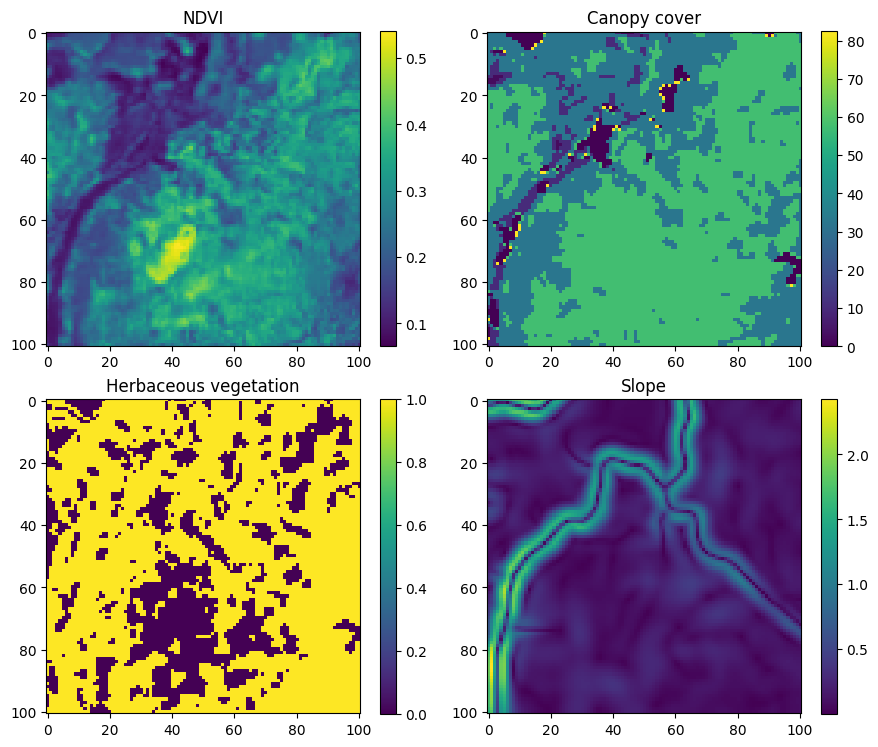

In [34]:
# Plot the covariates
fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

# Plot NDVI
im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
axs[0, 0].set_title('NDVI')
fig.colorbar(im1, ax=axs[0, 0])

# Plot Canopy cover
im2 = axs[0, 1].imshow(canopy_natural.numpy(), cmap='viridis')
axs[0, 1].set_title('Canopy cover')
fig.colorbar(im2, ax=axs[0, 1])

# Plot Herbaceous vegetation
im3 = axs[1, 0].imshow(herby_natural.numpy(), cmap='viridis')
axs[1, 0].set_title('Herbaceous vegetation')
fig.colorbar(im3, ax=axs[1, 0])

# Plot Slope
im4 = axs[1, 1].imshow(slope_natural.numpy(), cmap='viridis')
axs[1, 1].set_title('Slope')
fig.colorbar(im4, ax=axs[1, 1])

filename_covs = f'{base_path}/Python/outputs/model_training/covs_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'
plt.tight_layout()
# plt.savefig(filename_covs, dpi=600, bbox_inches='tight') # if we want to save the figure
plt.show()
plt.close()  # Close the figure to free memory

## Plot the target (observed location of the next step)

The model is trying to maximise the probability at the location of the next step, which is the target.

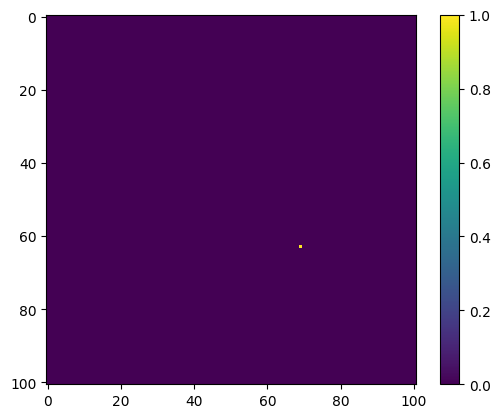

In [35]:
plt.imshow(target)
plt.colorbar()
plt.show()

# Define the model

Deep learning can be considered as a sequence of **blocks**, each of which perform some (typically nonlinear) transformation on input data to produce some output. Providing each block has the appropriate inputs, they can be combined to build a larger network that is capable of achieving complex and abstract transformations and can be used to represent complex processes.

A block is modular component of a neural network, in our case defined as a Python class (type of object with certain functionality described by its definition) inheriting from `torch.nn.Module` in PyTorch. A block encapsulates a sequence of operations, including layers (such as fully connected layers or convolutional layers) and activation functions, to process input data. Each block has a forward method (i.e. instructions) that defines the data flow through the network during inference or training.

## Define the parameters for the model

Here we enter the specific parameter values and hyperparameters for the model. These are the values that will be used to instantiate the model.

In [36]:
n_max_pool_layers = n_conv_layers # used to determine the number of inputs entering the fully connected block - needs to be manually changed if the number of max pooling layers is changed

params_dict = {"batch_size": 32, #number of samples in each batch
               "image_dim": 101, #number of pixels along the edge of each local patch/image
               "pixel_size": 25, #number of metres along the edge of a pixel
               "input_channels": 4 + 4, #number of spatial layers in each image + number of scalar layers that are converted to a grid
               "output_channels": 1, #number of convolution filters to learn
               "dim_in_nonspatial_to_grid": 4, #the number of scalar predictors that are converted to a grid and appended to the spatial features
               "dense_dim_in_nonspatial": 4, #change this to however many other scalar predictors you have (bearing, velocity etc)
               "dense_dim_hidden": 128, #number of nodes in the hidden layers
               "dense_dim_out": 128, #number of nodes in the output of the fully connected block (FCN)
               "dense_dim_in_all": 1, #number of inputs entering the fully connected block once the nonspatial features have been concatenated to the spatial features
               "kernel_size": 3, #the size of the 2D moving windows / kernels that are being learned
               "stride": 1, #the stride used when applying the kernel.  This reduces the dimension of the output if set to greater than 1
               "kernel_size_mp": 2, #the size of the kernel that is used in max pooling operations
               "stride_mp": 2, #the stride that is used in max pooling operations
               "padding": 1, #the amount of padding to apply to images prior to applying the 2D convolution
               "num_movement_params": 12, #number of parameters used to parameterise the movement kernel
               "dropout": 0.1, #the proportion of nodes that are dropped out in the dropout layers
               "device": device
               }

# Now update the dictionary with calculated values
params_dict["dense_dim_in_all"] = int(((params_dict["image_dim"] - (params_dict["image_dim"] % 2))**2) * (params_dict["output_channels"] / (4**n_max_pool_layers)))

## Instantiate the model

As described in the `deepSSF_train.ipynb` script, we saved the model definition into a file named `deepSSF_model.py`. We can instantiate the model by importing the file (which was done when importing other packages) and calling the classes parameter dictionary from that script.

In [37]:
params = deepSSF_model.ModelParams(params_dict)
model = deepSSF_model.ConvJointModel(params).to(device)
print(model)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (fcn_movement_all): FCN_block_all_movement(
    (ffn): Sequential(
      (0): Linear(in_features=625, out_features=128, bi

### Check that model is working and create scalar maps for plotting with the conv filters

In [38]:
# Create an instance of the scalar-to-grid block using model parameters
test_block = deepSSF_model.Scalar_to_Grid_Block(params)

# Convert scalars into spatial grid representation
scalar_maps = test_block(sample_temporal_covs)
# print(scalar_maps)  # Optionally, to inspect raw output
print(scalar_maps.shape)  # Check the shape of the generated spatial maps

torch.Size([1, 4, 101, 101])


## Set model hyperparameters

Set the learning rate, loss function, optimizer, scheduler and early stopping.

In [39]:
learning_rate = 1e-3

# Define the negative log-likelihood loss function with mean reduction
loss_fn = deepSSF_loss.negativeLogLikeLoss(reduction='mean')

# path to save the model weights
path_save_weights = f'{base_path}/Python/model_checkpoints/deepSSF_hyper-tune_buffalo{buffalo_id}_{today_date}.pt'

# Set up the Adam optimizer for updating the model's parameters
optimiser = optim.Adam(model.parameters(), lr=learning_rate)

# Create a learning rate scheduler that reduces the LR by a factor of 0.1
#    if validation loss has not improved for 'patience=5' epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,  # The optimizer whose learning rate will be adjusted
    mode='min', # The metric to be minimized (e.g., validation loss)
    factor=0.5, # Factor by which the learning rate will be reduced
    patience=5  # Number of epochs with no improvement before learning rate reduces
)

# EarlyStopping stops training after 'patience=10' epochs with no improvement,
#    optionally saving the best model weights
early_stopping = deepSSF_early_stopping.EarlyStopping(patience=15, verbose=True, path=path_save_weights)

## Training loop

This code defines the main training loop for a single epoch. It iterates over batches from the training dataloader, moves the data to the correct device (e.g., CPU or GPU), calculates the loss, and performs backpropagation to update the model parameters. It also prints periodic updates of the current loss.

In [40]:
def train_loop(dataloader_train, model, loss_fn, optimiser):
    """
    Runs the training process for one epoch using the given dataloader, model,
    loss function, and optimizer. Prints progress updates every few batches.
    """

    # 1. Total number of training examples
    num_train_batches = len(dataloader_train)
    size = len(dataloader_train.dataset)

    # 2. Put model in training mode (affects layers like dropout, batchnorm)
    model.train()

    # 3. Variable to accumulate the total loss over the epoch
    epoch_loss = 0.0

    # 4. Loop over batches in the training dataloader
    for batch, (x1, x2, x3, y) in enumerate(dataloader_train):

        # Move the batch of data to the specified device (CPU/GPU)
        x1 = x1.to(device)
        x2 = x2.to(device)
        x3 = x3.to(device)
        y = y.to(device)

        # Reset gradients before the next iteration
        optimiser.zero_grad()

        # Forward pass: compute the model output and loss
        loss = loss_fn(model((x1, x2, x3)), y)
        epoch_loss += loss

        # Backpropagation: compute gradients and update parameters
        loss.backward()
        optimiser.step()

        # Print an update every 5 batches to keep track of training progress
        if batch % 5 == 0:
            loss_val = loss.item()
            current = batch * bs + len(x1)
            print(f"loss: {loss_val:>15f}  [{current:>5d}/{size:>5d}]")

    # Compute the average training loss and print it
    epoch_loss /= num_train_batches
    print(f"\nAvg training loss:      {epoch_loss:>15f}")
    train_losses.append(epoch_loss.item())

## Test loop

The test loop is similar to the training loop, but it does not perform backpropagation. It calculates the loss on the test set and returns the average loss.

In [41]:
def test_loop(dataloader_test, model, loss_fn):
    """
    Evaluates the model on the provided test dataset by computing
    the average loss over all batches.
    No gradients are computed during this process (torch.no_grad()).
    """

    # 1. Set the model to evaluation mode (affects layers like dropout, batchnorm).
    model.eval()

    size = len(dataloader_test.dataset)
    num_batches = len(dataloader_test)

    test_loss = 0

    # 2. Disable gradient computation to speed up evaluation and reduce memory usage
    with torch.no_grad():
        # 3. Loop through each batch in the test dataloader
        for x1, x2, x3, y in dataloader_test:

            # Move the batch of data to the appropriate device (CPU/GPU)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = y.to(device)

            # Compute the loss on the test set (no backward pass needed)
            test_loss += loss_fn(model((x1, x2, x3)), y)

    # 4. Compute average test loss over all batches
    test_loss /= num_batches

    # Print the average test loss
    print(f"Avg test loss: {test_loss:>15f} \n")
    return test_loss.item()

## Train the model

In [ ]:
# epochs = 100
# train_losses = []  # Track training losses across epochs
# val_losses = []   # Track validation losses across epochs

# for t in range(epochs):

#     val_loss = 0.0
#     num_batches = len(dataloader_val)

#     print(f"Epoch {t+1}\n-------------------------------")

#     # 1. Run the training loop for one epoch using the training dataloader
#     train_loop(dataloader_train, model, loss_fn, optimiser)

#     # 2. Evaluate model performance on the validation dataset
#     model.eval()  # Switch to evaluation mode for proper layer behavior
#     with torch.no_grad():

#         # Loop through each batch in the validation dataloader
#         for x1, x2, x3, y in dataloader_val:
#             # Move data to the chosen device (CPU/GPU)
#             x1 = x1.to(device)
#             x2 = x2.to(device)
#             x3 = x3.to(device)
#             y = y.to(device)

#             # Accumulate validation loss
#             val_loss += loss_fn(model((x1, x2, x3)), y)

#     # 3. Step the scheduler based on the validation loss (adjusts learning rate if needed)
#     scheduler.step(val_loss)

#     # 4. Compute the average validation loss and print it, along with the current learning rate
#     val_loss /= num_batches
#     print(f"Avg validation loss:    {val_loss:>15f}")
#     print(f"Learning rate: {scheduler.get_last_lr()}")

#     # 5. Track the validation loss for plotting or monitoring
#     val_losses.append(val_loss)

#     # 6. Early stopping: if no improvement in validation loss for a set patience, stop training
#     early_stopping(val_loss, model)
#     if early_stopping.early_stop:
#         print("Early stopping")
#         # Restore the best model weights saved by EarlyStopping
#         model.load_state_dict(torch.load(path_save_weights, weights_only=True, map_location=device))
#         test_loop(dataloader_test, model, loss_fn)  # Evaluate on test set once training stops
#         break
#     else:
#         model.eval()
#         print("\n")

# print("Done!")

### Directory for saving outputs

In [42]:
# To save the outputs of the model, create a directory
hyper_tuning_dir = f'{base_path}/Python/outputs/hyper_tuning/id{buffalo_id}'
os.makedirs(hyper_tuning_dir, exist_ok=True)

# Iterate over hyperparameters

In [ ]:
n_conv_filters = [1, 2, 4, 8, 16]

# Create a DataFrame to store all results
results_df = pd.DataFrame(columns=[
    'num_conv_filters',      # Number of convolution filters
    'total_epochs',          # Number of epochs trained before early stopping
    'final_train_loss',      # Final training loss
    'avg_train_loss',        # Average training loss over all epochs
    'min_train_loss',        # Minimum training loss achieved
    'final_val_loss',        # Final validation loss
    'avg_val_loss',          # Average validation loss over all epochs
    'min_val_loss',          # Minimum validation loss achieved
    'test_loss',             # Loss on test set
    'training_time_seconds', # Total training time in seconds
    'training_date'          # Date and time of training
])

for j in n_conv_filters:

    # To save the outputs of the model, create a directory
    output_dir = f'{hyper_tuning_dir}/id{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}'
    os.makedirs(output_dir, exist_ok=True)

    # Start timing
    start_time = time.time()

    # Update the dictionary with calculated values
    params_dict["output_channels"] = j
    # Now update the dictionary with calculated values
    params_dict["dense_dim_in_all"] = int(((params_dict["image_dim"] - (params_dict["image_dim"] % 2))**2) * (params_dict["output_channels"] / (4**n_max_pool_layers)))

    params = deepSSF_model.ModelParams(params_dict)
    model = deepSSF_model.ConvJointModel(params).to(device)
    print(model)

    # Reinitialize optimizer for the new model
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-4)  # Adjust learning rate as needed
    # Reinitialize scheduler for the new model
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, 'min', factor=0.5, patience=5)

    # Update path to save the model weights
    path_save_weights = f'{output_dir}/deepSSF_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.pt'
    early_stopping = deepSSF_early_stopping.EarlyStopping(patience=15, verbose=True, path=path_save_weights)
    print(f'\n{path_save_weights}')


    print('\n################################################')
    print(f"Number of convolution filters: {j}")
    print('################################################\n')

    epochs = 100
    train_losses = []  # Track training losses across epochs
    val_losses = []   # Track validation losses across epochs

    for t in range(epochs):

      # Initialise variables to store during training
      train_loss = 0.0
      num_train_batches = len(dataloader_train)

      val_loss = 0.0
      num_batches = len(dataloader_val)

      print(f"Epoch {t+1}\n-------------------------------")

      # Run the model on the validation set before any training
      if t < 1:

        model.eval()  # Switch to evaluation mode for proper layer behavior

        with torch.no_grad():

            # Loop through each batch in the training dataloader
            for x1, x2, x3, y in dataloader_train:
                # Move data to the chosen device (CPU/GPU)
                x1 = x1.to(device)
                x2 = x2.to(device)
                x3 = x3.to(device)
                y = y.to(device)

                # Accumulate validation loss
                train_loss += loss_fn(model((x1, x2, x3)), y)

        train_loss /= num_train_batches
        print(f"Avg pre-training loss:  {train_loss:>15f}")
        train_losses.append(train_loss.item())

        with torch.no_grad():

            # Loop through each batch in the validation dataloader
            for x1, x2, x3, y in dataloader_val:
                # Move data to the chosen device (CPU/GPU)
                x1 = x1.to(device)
                x2 = x2.to(device)
                x3 = x3.to(device)
                y = y.to(device)

                # Accumulate validation loss
                val_loss += loss_fn(model((x1, x2, x3)), y)

        val_loss /= num_batches
        print(f"Avg validation loss:    {val_loss:>15f}")
        val_losses.append(val_loss.item())


      # 1. Run the training loop for one epoch using the training dataloader
      train_loop(dataloader_train, model, loss_fn, optimiser)

      # 2. Evaluate model performance on the validation dataset
      model.eval()  # Switch to evaluation mode for proper layer behavior
      with torch.no_grad():

          # Loop through each batch in the validation dataloader
          for x1, x2, x3, y in dataloader_val:
              # Move data to the chosen device (CPU/GPU)
              x1 = x1.to(device)
              x2 = x2.to(device)
              x3 = x3.to(device)
              y = y.to(device)

              # Accumulate validation loss
              val_loss += loss_fn(model((x1, x2, x3)), y)

      # 3. Step the scheduler based on the validation loss (adjusts learning rate if needed)
      scheduler.step(val_loss)

      # 4. Compute the average validation loss and print it, along with the current learning rate
      val_loss /= num_batches
      print(f"Avg validation loss:    {val_loss:>15f}")
      print(f"Learning rate: {scheduler.get_last_lr()}")

      # 5. Track the validation loss for plotting or monitoring
      val_losses.append(val_loss.item())

      # 6. Early stopping: if no improvement in validation loss for a set patience, stop training
      early_stopping(val_loss, model)
      if early_stopping.early_stop:
          print("Early stopping")
          # Restore the best model weights saved by EarlyStopping
          model.load_state_dict(torch.load(path_save_weights, weights_only=True, map_location=device))
          break
      else:
          model.eval()
          print("\n")

    # End timing
    end_time = time.time()
    training_time = end_time - start_time

    test_loss = test_loop(dataloader_test, model, loss_fn)  # Evaluate on test set once training stops

    # Add results to the DataFrame using pd.concat (modern alternative to append)
    new_row = pd.DataFrame({
        'num_conv_filters': [j],
        'total_epochs': [len(train_losses)],
        'final_train_loss': [train_losses[-1] if train_losses else None],
        'avg_train_loss': [np.mean(train_losses) if train_losses else None],
        'min_train_loss': [min(train_losses) if train_losses else None],
        'final_val_loss': [val_losses[-1] if val_losses else None],
        'avg_val_loss': [np.mean(val_losses) if val_losses else None],
        'min_val_loss': [min(val_losses) if val_losses else None],
        'test_loss': [test_loss],
        'training_time_seconds': [training_time],
        'training_date': [today_date]
    })
    results_df = pd.concat([results_df, new_row], ignore_index=True)

    print("Done!")

    # Save the current results (in case the script crashes later)
    results_path = f'{hyper_tuning_dir}/results_buffalo{buffalo_id}_nconv{n_conv_layers}_{today_date}.csv'
    results_df.to_csv(results_path, index=False)
    print(f"Results saved to {results_path}")

    # Clear memory before next iteration
    torch.cuda.empty_cache()

    # Print current best configuration
    best_idx = results_df['test_loss'].idxmin()
    best_config = results_df.loc[best_idx]
    print("\n################################################")
    print(f"Current best configuration: {best_config['num_conv_filters']} conv filters")
    print(f"Test loss: {best_config['test_loss']}")
    print("################################################\n")


    print('\n################################################')
    print(f"Testing the model with {j} convolution filters")
    print('################################################\n')

    # Put the model in evaluation mode (affects layers like dropout, batch norm, etc.)
    model.eval()
    # Pass the data through the model
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))


    # ------------------------------------------------------------------------

    # Directory for saving the loss dataframe
    filename_loss_csv = f'{output_dir}/deepSSF_val_loss_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.csv'
    filename_loss_png = f'{output_dir}/val_loss_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png'
    filename_train_loss_csv = f'{output_dir}/train_loss_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.csv'

    # Convert the list of tensors to a single tensor
    val_losses_tensor = torch.tensor(val_losses)
    # Number of epochs
    n_epochs = len(val_losses)
    print(f'Number of epochs: {n_epochs}')

    val_losses_df = pd.DataFrame({
        # "epoch": range(1, n_epochs + 1),
        "epoch": range(n_epochs),
        "val_losses": val_losses_tensor.detach().cpu().numpy()
    })

    # Save the validation losses to a CSV file
    val_losses_df.to_csv(filename_loss_csv, index=False)


    # Convert the list of tensors to a single tensor
    train_losses_tensor = torch.tensor(train_losses)

    # Determine the step interval (1/num_batches)
    step_interval = 1/len(train_losses)/n_epochs

    train_losses_df = pd.DataFrame({
        # "epoch": np.linspace(1, n_epochs, len(train_losses)),
        "epoch": np.linspace(0, n_epochs, len(train_losses)),
        "train_losses": train_losses
    })

    # Save the validation losses to a CSV file
    train_losses_df.to_csv(filename_train_loss_csv, index=False)

    # Plot the validation losses
    plt.plot(train_losses_df['epoch'], train_losses_df['train_losses'], label='Training Loss', color='blue')  # Plot training loss in blue
    plt.plot(val_losses_df['epoch'], val_losses_df['val_losses'], label='Validation Loss', color='red')  # Plot validation loss in red
    plt.title('Validation Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()  # Show legend to distinguish lines
    plt.savefig(filename_loss_png, dpi=600, bbox_inches='tight')
    plt.show()


    # Save model covariates in each folder
    # -------------------------------------------------------------------------

    # Plot the covariates
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # Plot NDVI
    im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
    axs[0, 0].set_title('NDVI')
    fig.colorbar(im1, ax=axs[0, 0])

    # Plot Canopy cover
    im2 = axs[0, 1].imshow(canopy_natural.numpy(), cmap='viridis')
    axs[0, 1].set_title('Canopy cover')
    fig.colorbar(im2, ax=axs[0, 1])

    # Plot Herbaceous vegetation
    im3 = axs[1, 0].imshow(herby_natural.numpy(), cmap='viridis')
    axs[1, 0].set_title('Herbaceous vegetation')
    fig.colorbar(im3, ax=axs[1, 0])

    # Plot Slope
    im4 = axs[1, 1].imshow(slope_natural.numpy(), cmap='viridis')
    axs[1, 1].set_title('Slope')
    fig.colorbar(im4, ax=axs[1, 1])

    filename_covs = f'{output_dir}/id{buffalo_id}_sample{iteration_index}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'
    plt.tight_layout()
    plt.savefig(filename_covs, dpi=600, bbox_inches='tight') # if we want to save the figure
    plt.show()
    plt.close()  # Close the figure to free memory

    # Print model outputs
    # -------------------------------------------------------------------------

    model.eval()
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))
    print(test.shape)

    # -------------------------------------------------------------------------
    # Extract and exponentiate the habitat density channel
    #    (at index 0 in the last dimension)
    # -------------------------------------------------------------------------
    hab_density = test.detach().cpu().numpy()[0, :, :, 0]
    hab_density_exp = np.exp(hab_density)
    # print(np.sum(hab_density_exp))  # Debug: check the sum of exponentiated values

    # -------------------------------------------------------------------------
    # Create masks to remove unwanted edge cells from visualization
    #    (setting them to -∞ affects the color scale in plots)
    # -------------------------------------------------------------------------
    x_mask = np.ones_like(hab_density)
    y_mask = np.ones_like(hab_density)

    x_mask[:, :3] = -np.inf
    x_mask[:, 98:] = -np.inf
    y_mask[:3, :] = -np.inf
    y_mask[98:, :] = -np.inf

    # -------------------------------------------------------------------------
    # Apply the masks to the habitat density (log scale) and exponentiated version
    # -------------------------------------------------------------------------
    hab_density_mask = hab_density * x_mask * y_mask
    hab_density_exp_mask = hab_density_exp * x_mask * y_mask

    # -------------------------------------------------------------------------
    # Plot and save the habitat density in log scale
    # -------------------------------------------------------------------------
    plt.imshow(hab_density_mask)
    plt.colorbar()
    plt.title('Habitat selection probability (log)')
    plt.savefig(f'{output_dir}/hab_log_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # Plot and save the habitat density in probability (exponentiated) scale
    # -------------------------------------------------------------------------
    plt.imshow(hab_density_exp_mask)
    plt.colorbar()
    plt.title('Habitat selection probability')
    plt.savefig(f'{output_dir}/hab_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # Extract and exponentiate the movement density channel
    #    (at index 1 in the last dimension)
    # -------------------------------------------------------------------------
    move_density = test.detach().cpu().numpy()[0, :, :, 1]
    move_density_exp = np.exp(move_density)
    # print(np.sum(move_density_exp))  # Debug: check the sum of exponentiated values

    # -------------------------------------------------------------------------
    # Apply the same masking strategy to movement densities
    # -------------------------------------------------------------------------
    move_density_mask = move_density * x_mask * y_mask
    move_density_exp_mask = move_density_exp * x_mask * y_mask

    # -------------------------------------------------------------------------
    # Plot and save the movement density in log scale
    # -------------------------------------------------------------------------
    plt.imshow(move_density_mask)
    plt.colorbar()
    plt.title('Movement probability (log)')
    plt.savefig(f'{output_dir}/move_log_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # Plot and save the movement density in probability (exponentiated) scale
    # -------------------------------------------------------------------------
    plt.imshow(move_density_exp_mask)
    plt.colorbar()
    plt.title('Movement probability')
    plt.savefig(f'{output_dir}/move_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # Compute the next-step density by adding habitat + movement (log-space)
    #     Then exponentiate and normalize
    # -------------------------------------------------------------------------
    step_density = test[0, :, :, 0] + test[0, :, :, 1]
    step_density = step_density.detach().cpu().numpy()
    step_density_exp = np.exp(step_density)
    # print('Sum of step density exp = ', np.sum(step_density_exp))  # Debug

    step_density_exp_norm = step_density_exp / np.sum(step_density_exp)
    # print('Sum of step density exp norm = ', np.sum(step_density_exp_norm))  # Debug

    # -------------------------------------------------------------------------
    # Apply masks to the step densities (log and exponentiated + normalized)
    # -------------------------------------------------------------------------
    step_density_mask = step_density * x_mask * y_mask
    step_density_exp_norm_mask = step_density_exp_norm * x_mask * y_mask

    # -------------------------------------------------------------------------
    # Plot and save the combined next-step probability surface in log scale
    # -------------------------------------------------------------------------
    plt.imshow(step_density_mask)
    plt.colorbar()
    plt.title('Next-step probability (log)')
    plt.savefig(f'{output_dir}/step_log_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    # -------------------------------------------------------------------------
    # Plot and save the combined next-step probability surface in probability scale
    # -------------------------------------------------------------------------
    plt.imshow(step_density_exp_norm_mask)
    plt.colorbar()
    plt.title('Next-step probability')
    plt.savefig(f'{output_dir}/step_prob_hyper-tune_buffalo{buffalo_id}_nconv{n_conv_layers}_filter{j}_{today_date}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    ## Convolutional layer 1
    ### Activation hook

    # -----------------------------------------------------------
    # Create a dictionary to store activation outputs
    # -----------------------------------------------------------
    activation = {}

    def get_activation(name):
        """
        Returns a hook function that can be registered on a layer
        to capture its output (i.e., feature maps) after the forward pass.

        Args:
            name (str): The key under which the activation is stored in the 'activation' dict.
        """
        def hook(model, input, output):
            # Detach and save the layer's output in the dictionary
            activation[name] = output.detach()
        return hook

    # -----------------------------------------------------------
    # Register a forward hook on the first convolution layer
    #    in the model's 'conv_habitat' block
    # -----------------------------------------------------------
    model.conv_habitat.conv2d[0].register_forward_hook(get_activation("hab_conv1"))

    # -----------------------------------------------------------
    # Perform a forward pass through the model with the desired input
    #    The feature maps from the hooked layer will be stored in 'activation'
    # -----------------------------------------------------------
    # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

    # -----------------------------------------------------------
    # Retrieve the captured feature maps from the dictionary
    #    and move them to the CPU for inspection
    # -----------------------------------------------------------
    feat_maps1 = activation["hab_conv1"].cpu()
    print("Feature map shape:", feat_maps1.shape)
    # Typically shape: (batch_size, out_channels, height, width)

    # -----------------------------------------------------------
    # Visualize the feature maps for the first sample in the batch
    # -----------------------------------------------------------
    feat_maps1_sample = feat_maps1[0]  # Shape: (out_channels, H, W)
    num_maps1 = feat_maps1_sample.shape[0]
    print("Number of feature maps:", num_maps1)


    ### Stack spatial and scalar (as grid) covariates
    covariate_stack = torch.cat([sample_spatial_covs.detach().to(device), scalar_maps], dim=1)
    print(covariate_stack.shape)
    covariate_names = ['NDVI', 'Canopy cover', 'Herbaceous vegetation', 'Slope',
                    'Hour sin', 'Hour cos', 'yday sin', 'yday cos']


    ### Extract filters and plot

    # -------------------------------------------------------------------------
    # Check or print the convolution layer in conv_habitat (for debugging)
    # -------------------------------------------------------------------------
    print(model.conv_habitat.conv2d)

    # -------------------------------------------------------------------------
    # Set the model to evaluation mode (disables dropout, etc.)
    # -------------------------------------------------------------------------
    model.eval()

    # -------------------------------------------------------------------------
    # Extract the weights (filters) from the first convolution layer in conv_habitat
    # -------------------------------------------------------------------------
    filters_c1 = model.conv_habitat.conv2d[0].weight.data.clone().cpu()
    print("Filters shape:", filters_c1.shape)
    # Typically (out_channels, in_channels, kernel_height, kernel_width)

    # -------------------------------------------------------------------------
    # Visualize each filter’s first channel in a grid of subplots
    # -------------------------------------------------------------------------
    num_filters_c1 = filters_c1.shape[1]
    print(num_filters_c1)

    for z in range(num_maps1):

        fig, axes = plt.subplots(2, num_filters_c1, figsize=(2*num_filters_c1, 4))
        for i in range(num_filters_c1):

            # Add the covariates as the first row of subplots
            axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
            axes[0,i].axis('off')
            axes[0,i].set_title(f'{covariate_names[i]}')
            if i > 3:
                im1 = axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
                im1.set_clim(-1, 1)
                axes[0,i].text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
                    f'Value: {round(x2[0, i-4].item(), 2)}',
                    ha='center', va='center', color='white', fontsize=12)

            kernel = filters_c1[z, i, :, :]  # Show the first input channel
            im = axes[1,i].imshow(kernel, cmap='viridis')
            axes[1,i].axis('off')
            axes[1,i].set_title(f'Layer 1, Filter {z+1}')
            # Annotate each cell with the numeric value
            for (j, k), val in np.ndenumerate(kernel):
                axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer1_filters{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


        # -----------------------------------------------------------
        # Loop over each feature map channel and save them as images.
        #    Multiply by x_mask * y_mask if you need to mask out edges.
        # -----------------------------------------------------------

        plt.figure()
        plt.imshow(feat_maps1_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
        plt.title(f"Layer 1, Feature Map {z+1}")
        # Hide axis if you prefer: plt.axis('off')
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer1_feature_map{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


    ## Convolutional layer 2
    ### Activation hook

    # -----------------------------------------------------------
    # Register a forward hook on the second convolution layer
    #    in the model's 'conv_habitat' block
    # -----------------------------------------------------------
    model.conv_habitat.conv2d[2].register_forward_hook(get_activation("hab_conv2"))

    # -----------------------------------------------------------
    # Perform a forward pass through the model with the desired input
    #    The feature maps from the hooked layer will be stored in 'activation'
    # -----------------------------------------------------------
    # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

    # -----------------------------------------------------------
    # Retrieve the captured feature maps from the dictionary
    #    and move them to the CPU for inspection
    # -----------------------------------------------------------
    feat_maps2 = activation["hab_conv2"].cpu()
    print("Feature map shape:", feat_maps2.shape)
    # Typically shape: (batch_size, out_channels, height, width)

    # -----------------------------------------------------------
    # Visualize the feature maps for the first sample in the batch
    # -----------------------------------------------------------
    feat_maps2_sample = feat_maps2[0]  # Shape: (out_channels, H, W)
    num_maps2 = feat_maps2_sample.shape[0]
    print("Number of feature maps:", num_maps2)


    ### Extract filters and plot

    # -------------------------------------------------------------------------
    # Extract the weights (filters) from the second convolution layer in conv_habitat
    # -------------------------------------------------------------------------
    filters_c2 = model.conv_habitat.conv2d[2].weight.data.clone().cpu()
    print("Filters shape:", filters_c2.shape)
    # Typically (out_channels, in_channels, kernel_height, kernel_width)

    # -------------------------------------------------------------------------
    # Visualize each filter’s first channel in a grid of subplots
    # -------------------------------------------------------------------------
    num_filters_c2 = filters_c2.shape[1]
    print(num_filters_c2)

    for z in range(num_maps2):

        if num_filters_c2 == 1:

            # Handle the special case of a single filter
            fig, axes = plt.subplots(2, 1, figsize=(4, 8))

            # For the first filter
            axes[0].imshow(feat_maps1_sample[0].numpy() * x_mask * y_mask, cmap='viridis')
            axes[0].axis('off')
            axes[0].set_title(f"Layer 1, Map {z+1}")

            kernel = filters_c2[z, 0, :, :]
            axes[1].imshow(kernel, cmap='viridis')
            axes[1].axis('off')
            axes[1].set_title(f'Layer 2, Filter {z+1}')

            # Annotate each cell with the numeric value
            for (j, k), val in np.ndenumerate(kernel):
                axes[1].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

        else:

            # Original code for multiple filters
            fig, axes = plt.subplots(2, num_filters_c2, figsize=(2*num_filters_c2, 4))
            for i in range(num_filters_c2):
                # Add the previous feature maps as the first row of subplots
                axes[0,i].imshow(feat_maps1_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
                axes[0,i].axis('off')
                axes[0,i].set_title(f"Layer 1, Map {z+1}")

                kernel = filters_c2[z, i, :, :]
                axes[1,i].imshow(kernel, cmap='viridis')
                axes[1,i].axis('off')
                axes[1,i].set_title(f'Layer 2, Filter {z+1}')

                # Annotate each cell with the numeric value
                for (j, k), val in np.ndenumerate(kernel):
                    axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer2_filters{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


        # -----------------------------------------------------------
        # 6. Loop over each feature map channel and save them as images.
        #    Multiply by x_mask * y_mask if you need to mask out edges.
        # -----------------------------------------------------------

        plt.figure()
        plt.imshow(feat_maps2_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
        plt.title(f"Layer 2, Feature Map {z+1}")
        # Hide axis if you prefer: plt.axis('off')
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer2_feature_map{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


    ## Convolutional layer 3
    ### Activation hook
    # -----------------------------------------------------------
    # Register a forward hook on the third convolution layer
    #    in the model's 'conv_habitat' block
    # -----------------------------------------------------------
    model.conv_habitat.conv2d[4].register_forward_hook(get_activation("hab_conv3"))

    # -----------------------------------------------------------
    # Perform a forward pass through the model with the desired input
    #    The feature maps from the hooked layer will be stored in 'activation'
    # -----------------------------------------------------------
    # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

    # -----------------------------------------------------------
    # Retrieve the captured feature maps from the dictionary
    #    and move them to the CPU for inspection
    # -----------------------------------------------------------
    feat_maps3 = activation["hab_conv3"].cpu()
    print("Feature map shape:", feat_maps3.shape)
    # Typically shape: (batch_size, out_channels, height, width)

    # -----------------------------------------------------------
    # Visualize the feature maps for the first sample in the batch
    # -----------------------------------------------------------
    feat_maps3_sample = feat_maps3[0]  # Shape: (out_channels, H, W)
    num_maps3 = feat_maps3_sample.shape[0]
    print("Number of feature maps:", num_maps3)

    ### Extract filters and plot
    # -------------------------------------------------------------------------
    # Extract the weights (filters) from the second convolution layer in conv_habitat
    # -------------------------------------------------------------------------
    filters_c3 = model.conv_habitat.conv2d[4].weight.data.clone().cpu()
    print("Filters shape:", filters_c3.shape)
    # Typically (out_channels, in_channels, kernel_height, kernel_width)

    # -------------------------------------------------------------------------
    # Visualize each filter’s first channel in a grid of subplots
    # -------------------------------------------------------------------------
    num_filters_c3 = filters_c3.shape[1]
    print(num_filters_c3)

    for z in range(num_maps3):

        num_filters_c3 = filters_c3.shape[1]
        print(f"Number of filters in layer 3: {num_filters_c3}")

        if num_filters_c3 == 1:

            # Handle the special case of a single filter
            fig, axes = plt.subplots(2, 1, figsize=(4, 8))

            # For the first filter
            axes[0].imshow(feat_maps2_sample[0].numpy() * x_mask * y_mask, cmap='viridis')
            axes[0].axis('off')
            axes[0].set_title(f"Layer 2, Map {z+1}")

            kernel = filters_c3[z, 0, :, :]  # Show the first input channel
            im = axes[1].imshow(kernel, cmap='viridis')
            axes[1].axis('off')
            axes[1].set_title(f'Layer 3, Filter {z+1}')

            # Annotate each cell with the numeric value
            for (j, k), val in np.ndenumerate(kernel):
                axes[1].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

        else:

            # Original code for multiple filters
            fig, axes = plt.subplots(2, num_filters_c3, figsize=(2*num_filters_c3, 4))
            for i in range(num_filters_c3):
                # Add the covariates as the first row of subplots
                axes[0,i].imshow(feat_maps2_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
                axes[0,i].axis('off')
                axes[0,i].set_title(f"Layer 2, Map {z+1}")

                kernel = filters_c3[z, i, :, :]  # Show the first input channel
                im = axes[1,i].imshow(kernel, cmap='viridis')
                axes[1,i].axis('off')
                axes[1,i].set_title(f'Layer 3, Filter {z+1}')

                # Annotate each cell with the numeric value
                for (j, k), val in np.ndenumerate(kernel):
                    axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer3_filters{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


        # -----------------------------------------------------------
        # 6. Loop over each feature map channel and save them as images.
        #    Multiply by x_mask * y_mask if you need to mask out edges.
        # -----------------------------------------------------------

        plt.figure()
        plt.imshow(feat_maps3_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
        plt.title(f"Habitat selection log probability")
        # Hide axis if you prefer: plt.axis('off')
        plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer3_feature_map{z}.png', dpi=600, bbox_inches='tight')
        plt.show()


    # Checking estimated movement parameters
    # Similarly to the convolutional layers, we can set hooks to extract the predicted movement parameters from the model, and assess how variable that is across samples.
    # -------------------------------------------------------------------------
    # Create a list to store the intermediate output from the fully connected
    #    movement sub-network (fcn_movement_all)
    # -------------------------------------------------------------------------
    intermediate_output = []

    def hook(module, input, output):
        """
        Hook function that captures the output of the specified layer
        (fcn_movement_all) during the forward pass.
        """
        intermediate_output.append(output)

    # -------------------------------------------------------------------------
    # Register the forward hook on 'fcn_movement_all', so its outputs
    #    are recorded every time the model does a forward pass.
    # -------------------------------------------------------------------------
    hook_handle = model.fcn_movement_all.register_forward_hook(hook)

    # -------------------------------------------------------------------------
    # Perform a forward pass with the model in evaluation mode,
    #    disabling gradient computation.
    # -------------------------------------------------------------------------
    model.eval()
    with torch.no_grad():
      # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
      test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

    # -------------------------------------------------------------------------
    # Inspect the captured intermediate output
    #    'intermediate_output[0]' corresponds to the first (and only) forward pass.
    # -------------------------------------------------------------------------
    print("Intermediate output shape:", intermediate_output[0].shape)
    print("Intermediate output values:", intermediate_output[0][0])

    # -------------------------------------------------------------------------
    # Remove the hook to avoid repeated capturing in subsequent passes
    # -------------------------------------------------------------------------
    hook_handle.remove()

    # -------------------------------------------------------------------------
    # Unpack the parameters from the FCN output (assumes a specific ordering)
    # -------------------------------------------------------------------------
    gamma_shape1, gamma_scale1, gamma_weight1, \
    gamma_shape2, gamma_scale2, gamma_weight2, \
    vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
    vonmises_mu2, vonmises_kappa2, vonmises_weight2 = intermediate_output[0][0]

    # -------------------------------------------------------------------------
    # Convert parameters from log-space (if applicable) and print them
    #    Gamma and von Mises parameters
    # -------------------------------------------------------------------------
    # --- Gamma #1 ---
    print("Gamma shape 1:", torch.exp(gamma_shape1))
    print("Gamma scale 1:", torch.exp(gamma_scale1))
    print("Gamma weight 1:",
        torch.exp(gamma_weight1) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

    # --- Gamma #2 ---
    print("Gamma shape 2:", torch.exp(gamma_shape2))
    print("Gamma scale 2:", torch.exp(gamma_scale2) * 500)  # scale factor 500
    print("Gamma weight 2:",
        torch.exp(gamma_weight2) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

    # --- von Mises #1 ---
    # % (2*np.pi) ensures the mu (angle) is wrapped within [0, 2π)
    print("Von Mises mu 1:", vonmises_mu1 % (2*np.pi))
    print("Von Mises kappa 1:", torch.exp(vonmises_kappa1))
    print("Von Mises weight 1:",
        torch.exp(vonmises_weight1) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))

    # --- von Mises #2 ---
    print("Von Mises mu 2:", vonmises_mu2 % (2*np.pi))
    print("Von Mises kappa 2:", torch.exp(vonmises_kappa2))
    print("Von Mises weight 2:",
        torch.exp(vonmises_weight2) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))


    ## Plot the movement distributions
    # We can use the movement parameters to plot the step length and turning angle distributions for the sample covariates.


    # -------------------------------------------------------------------------
    # Define helper functions for calculating Gamma and von Mises log-densities
    # -------------------------------------------------------------------------
    def gamma_density(x, shape, scale):
        """
        Computes the log of the Gamma density for each value in x.

        Args:
        x (Tensor): Input values for which to compute the density.
        shape (float): Gamma shape parameter
        scale (float): Gamma scale parameter

        Returns:
        Tensor: The log of the Gamma probability density at each x.
        """
        return -1*torch.lgamma(shape) - shape*torch.log(scale) \
            + (shape - 1)*torch.log(x) - x/scale

    def vonmises_density(x, kappa, vm_mu):
        """
        Computes the log of the von Mises density for each value in x.

        Args:
        x (Tensor): Input angles in radians.
        kappa (float): Concentration parameter (kappa)
        vm_mu (float): Mean direction parameter (mu)

        Returns:
        Tensor: The log of the von Mises probability density at each x.
        """
        return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


    # -------------------------------------------------------------------------
    # Round and display the mixture weights for the Gamma distributions
    # -------------------------------------------------------------------------
    gamma_weight1_recovered = torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
    rounded_gamma_weight1 = round(gamma_weight1_recovered.item(), 2)

    gamma_weight2_recovered = torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
    rounded_gamma_weight2 = round(gamma_weight2_recovered.item(), 2)

    # -------------------------------------------------------------------------
    # Round and display the mixture weights for the von Mises distributions
    # -------------------------------------------------------------------------
    vonmises_weight1_recovered = torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
    rounded_vm_weight1 = round(vonmises_weight1_recovered.item(), 2)

    vonmises_weight2_recovered = torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
    rounded_vm_weight2 = round(vonmises_weight2_recovered.item(), 2)


    # -------------------------------------------------------------------------
    # 1. Plotting the Gamma mixture distribution
    #    a) Generate x values
    #    b) Compute individual Gamma log densities
    #    c) Exponentiate and combine using recovered weights
    # -------------------------------------------------------------------------
    x_values = torch.linspace(1, 101, 1000).to(device)
    gamma1_density = gamma_density(x_values, torch.exp(gamma_shape1), torch.exp(gamma_scale1))
    gamma2_density = gamma_density(x_values, torch.exp(gamma_shape2), torch.exp(gamma_scale2)*500)
    gamma_mixture_density = gamma_weight1_recovered*torch.exp(gamma1_density) \
                            + gamma_weight2_recovered*torch.exp(gamma2_density)

    # Move results to CPU and convert to NumPy for plotting
    x_values_np = x_values.cpu().numpy()
    gamma1_density_np = np.exp(gamma1_density.cpu().numpy())
    gamma2_density_np = np.exp(gamma2_density.cpu().numpy())
    gamma_mixture_density_np = gamma_mixture_density.cpu().numpy()

    # -------------------------------------------------------------------------
    # 2. Plot the Gamma distributions and their mixture
    # -------------------------------------------------------------------------
    filename_gamma_distributions = f'{output_dir}/id{buffalo_id}_gamma_distributions_{today_date}.png'

    plt.plot(x_values_np, gamma1_density_np, label=f'Gamma 1 Density: weight = {rounded_gamma_weight1}')
    plt.plot(x_values_np, gamma2_density_np, label=f'Gamma 2 Density: weight = {rounded_gamma_weight2}')
    plt.plot(x_values_np, gamma_mixture_density_np, label='Gamma Mixture Density')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.title('Gamma Density Function')
    plt.legend()
    plt.savefig(filename_gamma_distributions, dpi=600, bbox_inches='tight')
    plt.show()


    # -------------------------------------------------------------------------
    # 3. Plotting the von Mises mixture distribution
    #    a) Generate x values from -π to π
    #    b) Compute individual von Mises log densities
    #    c) Exponentiate and combine using recovered weights
    # -------------------------------------------------------------------------
    x_values = torch.linspace(-np.pi, np.pi, 1000).to(device)
    vonmises1_density = vonmises_density(x_values, torch.exp(vonmises_kappa1), vonmises_mu1)
    vonmises2_density = vonmises_density(x_values, torch.exp(vonmises_kappa2), vonmises_mu2)
    vonmises_mixture_density = vonmises_weight1_recovered*torch.exp(vonmises1_density) \
                            + vonmises_weight2_recovered*torch.exp(vonmises2_density)

    # Move results to CPU and convert to NumPy for plotting
    x_values_np = x_values.cpu().numpy()
    vonmises1_density_np = np.exp(vonmises1_density.cpu().numpy())
    vonmises2_density_np = np.exp(vonmises2_density.cpu().numpy())
    vonmises_mixture_density_np = vonmises_mixture_density.cpu().numpy()

    # -------------------------------------------------------------------------
    # 4. Plot the von Mises distributions and their mixture
    # -------------------------------------------------------------------------
    filename_vonmises_distributions = f'{output_dir}/id{buffalo_id}_vonmises_distributions_{today_date}.png'

    plt.plot(x_values_np, vonmises1_density_np, label=f'Von Mises 1 Density: weight = {rounded_vm_weight1}')
    plt.plot(x_values_np, vonmises2_density_np, label=f'Von Mises 2 Density: weight = {rounded_vm_weight2}')
    plt.plot(x_values_np, vonmises_mixture_density_np, label='Von Mises Mixture Density')
    plt.xlabel('x (radians)')
    plt.ylabel('Density')
    plt.title('Von Mises Density Function')
    plt.ylim(0, 1.2)  # Set a limit for the y-axis
    plt.legend()
    plt.savefig(filename_vonmises_distributions, dpi=600, bbox_inches='tight')
    plt.show()


    ## Generate a distribution of movement parameters

    print(f'There are {len(dataset_test)} samples in the test dataset')
    bs = len(dataset_test) # batch size
    dataloader_test = DataLoader(dataset=dataset_test, batch_size=bs, shuffle=True)

    # -----------------------------------------------------------
    # Fetch a batch of data from the training dataloader
    # -----------------------------------------------------------
    spatial_covs_batch, temporal_covs_batch, prev_bearing_batch, labels = next(iter(dataloader_test))

    # Move the input batches to the same device as the model
    spatial_covs_batch = spatial_covs_batch.to(device)
    temporal_covs_batch = temporal_covs_batch.to(device)
    prev_bearing_batch = prev_bearing_batch.to(device)


    # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
    test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

    # -----------------------------------------------------------
    # Register a forward hook to capture the outputs
    #    from 'fcn_movement_all' during the forward pass
    # -----------------------------------------------------------
    hook_handle = model.fcn_movement_all.register_forward_hook(hook)

    # -----------------------------------------------------------
    # Perform a forward pass in evaluation mode to generate
    #    and capture the sub-network's outputs in 'intermediate_output'
    # -----------------------------------------------------------
    model.eval()  # Disables certain layers like dropout

    # Pass the batch through the model
    # We re-run the model to capture the feature maps using the hooks (which require a forward pass through the model)
    # But this time we are using the test dataset as a batch
    test_batch = model((spatial_covs_batch, temporal_covs_batch, prev_bearing_batch))

    # -----------------------------------------------------------
    # Prepare lists to store the distribution parameters
    #    for each sample in the batch
    # -----------------------------------------------------------
    gamma_shape1_list = []
    gamma_scale1_list = []
    gamma_weight1_list = []
    gamma_shape2_list = []
    gamma_scale2_list = []
    gamma_weight2_list = []
    vonmises_mu1_list = []
    vonmises_kappa1_list = []
    vonmises_weight1_list = []
    vonmises_mu2_list = []
    vonmises_kappa2_list = []
    vonmises_weight2_list = []

    # -----------------------------------------------------------
    # Extract parameters from 'intermediate_output'
    #    for every sample in the batch
    # -----------------------------------------------------------
    for batch_output in intermediate_output:
        # Each 'batch_output' corresponds to one forward pass;
        # it might contain multiple samples if the batch size > 1
        for sample_output in batch_output:
            # Unpack the 12 parameters of the Gamma and von Mises mixtures
            gamma_shape1, gamma_scale1, gamma_weight1, \
            gamma_shape2, gamma_scale2, gamma_weight2, \
            vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
            vonmises_mu2, vonmises_kappa2, vonmises_weight2 = sample_output

            # Convert log-space parameters to real space, then store
            gamma_shape1_list.append(torch.exp(gamma_shape1).item())
            gamma_scale1_list.append(torch.exp(gamma_scale1).item())
            gamma_weight1_list.append(
                (torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
            )
            gamma_shape2_list.append(torch.exp(gamma_shape2).item())
            gamma_scale2_list.append((torch.exp(gamma_scale2)*500).item())  # scale factor 500
            gamma_weight2_list.append(
                (torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
            )
            vonmises_mu1_list.append((vonmises_mu1 % (2*np.pi)).item())
            vonmises_kappa1_list.append(torch.exp(vonmises_kappa1).item())
            vonmises_weight1_list.append(
                (torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
            )
            vonmises_mu2_list.append((vonmises_mu2 % (2*np.pi)).item())
            vonmises_kappa2_list.append(torch.exp(vonmises_kappa2).item())
            vonmises_weight2_list.append(
                (torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
            )


    ### Plot the distribution of movement parameters
    # -----------------------------------------------------------
    # Define a helper function to plot histograms
    #    for the collected parameters
    # -----------------------------------------------------------
    def plot_histogram(data, title, xlabel):
        """
        Plots a histogram of the provided data.

        Args:
            data (list): Data points to plot in a histogram.
            title (str): Title of the histogram plot.
            xlabel (str): X-axis label.
        """
        plt.figure()
        plt.hist(data, bins=30, alpha=0.75)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel('Frequency')

        # Generate a filename from the title (replace spaces with underscores)
        filename = title.replace(' ', '_') + '.png'
        filepath = os.path.join(output_dir, filename)

        # Save the figure
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()  # Close the figure to free memory

    # -----------------------------------------------------------
    # Plot histograms for each parameter distribution
    # -----------------------------------------------------------
    plot_histogram(gamma_shape1_list, 'Gamma Shape 1 Distribution', 'Shape 1')
    plot_histogram(gamma_scale1_list, 'Gamma Scale 1 Distribution', 'Scale 1')
    plot_histogram(gamma_weight1_list, 'Gamma Weight 1 Distribution', 'Weight 1')
    plot_histogram(gamma_shape2_list, 'Gamma Shape 2 Distribution', 'Shape 2')
    plot_histogram(gamma_scale2_list, 'Gamma Scale 2 Distribution', 'Scale 2')
    plot_histogram(gamma_weight2_list, 'Gamma Weight 2 Distribution', 'Weight 2')
    plot_histogram(vonmises_mu1_list, 'Von Mises Mu 1 Distribution', 'Mu 1')
    plot_histogram(vonmises_kappa1_list, 'Von Mises Kappa 1 Distribution', 'Kappa 1')
    plot_histogram(vonmises_weight1_list, 'Von Mises Weight 1 Distribution', 'Weight 1')
    plot_histogram(vonmises_mu2_list, 'Von Mises Mu 2 Distribution', 'Mu 2')
    plot_histogram(vonmises_kappa2_list, 'Von Mises Kappa 2 Distribution', 'Kappa 2')
    plot_histogram(vonmises_weight2_list, 'Von Mises Weight 2 Distribution', 'Weight 2')

    # -----------------------------------------------------------
    # Remove the hook to stop capturing outputs
    #    in subsequent forward passes
    # -----------------------------------------------------------
    hook_handle.remove()

    # Clear any hooks from previous models
    for module in model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()

# After all iterations, save the final results
final_results_path = f'{hyper_tuning_dir}/final_results_buffalo{buffalo_id}_nconv{n_conv_layers}_{today_date}.csv'
results_df.to_csv(final_results_path, index=False)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (fcn_movement_all): FCN_block_all_movement(
    (ffn): Sequential(
      (0): Linear(in_features=625, out_features=128, bi

In [ ]:
# Read the results dataframe back in
final_results_path = f'{hyper_tuning_dir}/final_results_buffalo{buffalo_id}_nconv{n_conv_layers}_{today_date}.csv'
results_df = pd.read_csv(final_results_path)

# Create a summary DataFrame sorted by test loss
summary_df = results_df[['num_conv_filters', 'min_val_loss', 'test_loss', 'total_epochs']].sort_values('test_loss')
print("\nSummary of Results (Sorted by Test Loss):")
print(summary_df)

# Visualization of results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot test and validation losses vs number of filters
plt.subplot(2, 2, 1)
plt.plot(results_df['num_conv_filters'], results_df['test_loss'], 'bo-', label='Test Loss')
plt.plot(results_df['num_conv_filters'], results_df['min_val_loss'], 'ro-', label='Min Validation Loss')
plt.xlabel('Number of Conv Filters')
plt.ylabel('Loss')
plt.title('Test and Validation Loss vs. Filters')
plt.legend()
plt.grid(True)

# Plot training time vs number of filters
plt.subplot(2, 2, 2)
plt.plot(results_df['num_conv_filters'], results_df['training_time_seconds']/60, 'go-')
plt.xlabel('Number of Conv Filters')
plt.ylabel('Training Time (minutes)')
plt.title('Training Time vs. Filters')
plt.grid(True)

# Plot epochs trained vs number of filters
plt.subplot(2, 2, 3)
plt.plot(results_df['num_conv_filters'], results_df['total_epochs'], 'mo-')
plt.xlabel('Number of Conv Filters')
plt.ylabel('Epochs until Early Stopping')
plt.title('Training Duration vs. Filters')
plt.grid(True)

# Plot min training loss vs min validation loss
plt.subplot(2, 2, 4)
plt.scatter(results_df['min_train_loss'], results_df['min_val_loss'], c=results_df['num_conv_filters'], cmap='viridis', s=100)
plt.colorbar(label='Num Conv Filters')
plt.xlabel('Min Training Loss')
plt.ylabel('Min Validation Loss')
plt.title('Training vs. Validation Loss')
plt.grid(True)

plt.tight_layout()
results_viz_path = f'{base_path}/Python/outputs/hyper_tuning/results_visualization_buffalo{buffalo_id}_{today_date}.png'
plt.savefig(results_viz_path, dpi=300, bbox_inches='tight')
plt.show()